# Privacy Pipeline — Experiment Notebook

End-to-end workflow:
1. Load config from `experiment.yaml`
2. Load and preprocess dataset → `Dataset`
3. (Optional) Inspect k-NN graph → `GraphDiagnostics`
4. Run epsilon sweep → `ExperimentResults` with typed records
5. Inspect typed results (noise metadata, attack results, per-ε records)
6. Plot privacy–utility tradeoff and Fiedler evolution
7. Deep-dive: clean embedding classification

Change `experiment.yaml` to switch datasets, mechanisms, or epsilons — no code edits needed.

In [ ]:
from privacy_pipeline import (
    # Config
    load_config, PrivacyExperiment,
    # Pipeline
    DPLaplacianEigenmaps, EmbeddingResult,
    # Graph
    diagnose_knn_graph, GraphDiagnostics, visualize_knn_graph,
    # Noise
    SpectralGapNoise, SpectralGapMetadata, build_noise_mechanism,
    # Evaluate
    run_classification, run_attack_all_classes,
    display_classification_results,
    ClassifierResult, AttackResult,
    # Features
    Dataset,
    # Results
    ExperimentResults, EpsilonRecord, FiedlerRecord, BaselineRecord,
    # Plots
    plot_privacy_utility_tradeoff, plot_fiedler_evolution,
)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

cfg = load_config('paderborn_experiment.yaml')
print(cfg)

ExperimentConfig(data=DataConfig(file_path='paderborn_subset.csv', meta_cols=['file_id', 'experiment', 'fault_size', 'load'], label_col='label', feature_groups=None), graph=GraphConfig(n_neighbors=27, normalized=True), embedding=EmbeddingConfig(n_components=4), noise=NoiseConfig(mechanism='spectral_gap', epsilons=[0.1, 0.25, 0.5, 0.75, 1.0, 2.0], params={'snr_target': 0.525}), evaluation=EvaluationConfig(n_splits=10, random_state=42), output=OutputConfig(results_dir='results_paderborn', figures_dir='figures', save_csv=True, save_figures=True, dpi=300))


In [9]:
# ── Load & preprocess dataset → Dataset ───────────────────────────────────────
experiment = PrivacyExperiment(cfg)
ds = experiment.load_data()          # returns Dataset(X, y, target_names)
print(ds)                            # Dataset(samples=..., features=..., classes=[...])

X_scaled, y, target_names = ds       # NamedTuple: still unpackable as a 3-tuple

Dataset(samples=8767, features=127, classes=['IR', 'Normal', 'OR'])


In [10]:
# ── (Optional) Inspect k-NN graph → GraphDiagnostics ─────────────────────────
from sklearn.neighbors import kneighbors_graph
A = kneighbors_graph(X_scaled, n_neighbors=cfg.graph.n_neighbors,
                     mode='distance', include_self=False, n_jobs=-1)
A = 0.5 * (A + A.T)

diag: GraphDiagnostics = diagnose_knn_graph(A)
print(diag)
print(f"  Connected : {diag.is_connected}")
print(f"  Components: {diag.n_components}")
print(f"  Nodes / Edges: {diag.n_nodes} / {diag.n_edges}")
print(f"  Degree  min={diag.degree_min:.1f}  mean={diag.degree_mean:.1f}  max={diag.degree_max:.1f}")
if not diag.is_connected:
    print(f"  Component sizes: {diag.component_sizes}")

GraphDiagnostics(nodes=8767, edges=194623, connected, degree=63.2/199.5/1074.1)
  Connected : True
  Components: 1
  Nodes / Edges: 8767 / 194623
  Degree  min=63.2  mean=199.5  max=1074.1


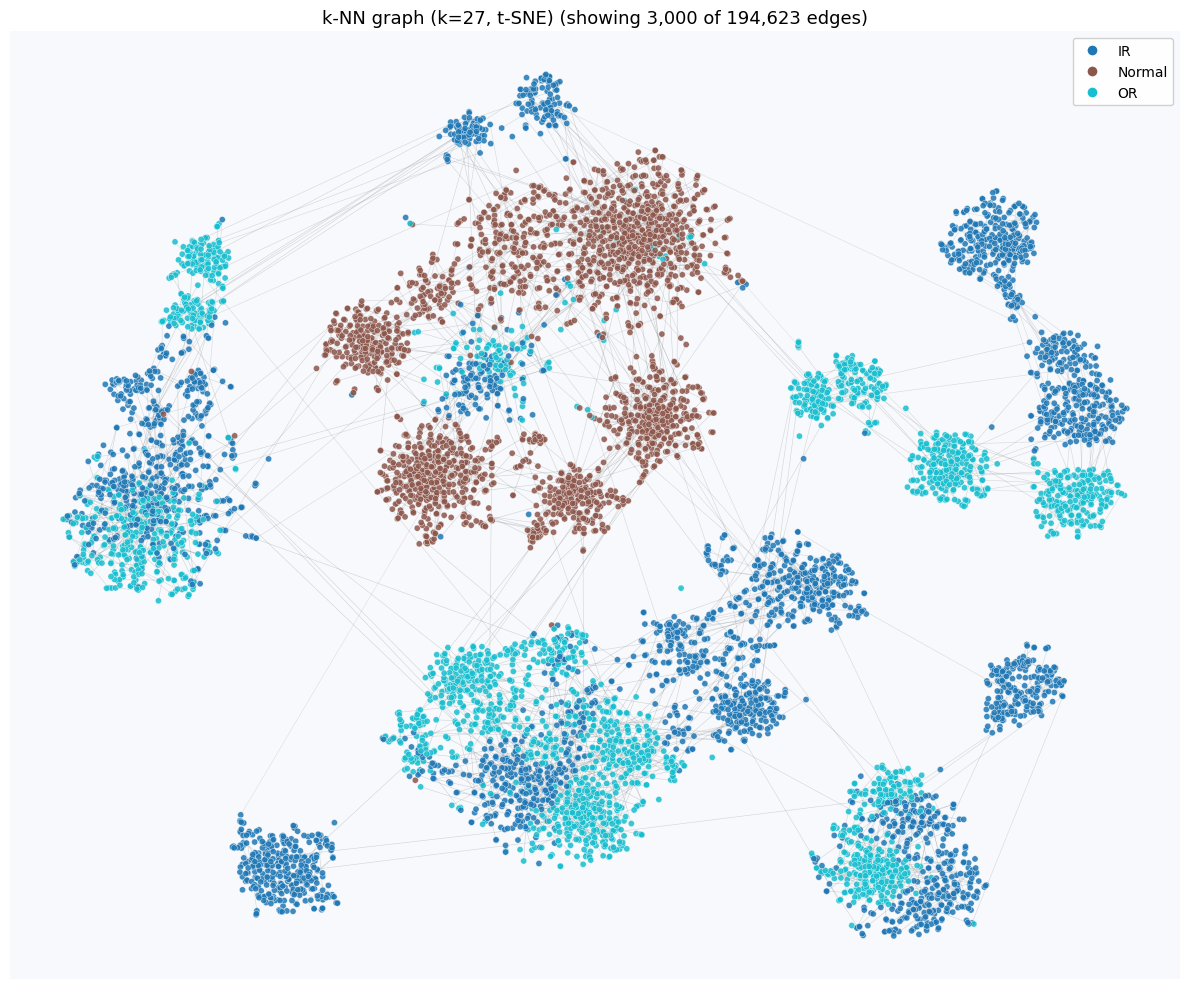

In [11]:
# ── (Optional) Visualize k-NN graph ──────────────────────────────────────────
fig = visualize_knn_graph(X_scaled, y, target_names=list(target_names),
                          n_neighbors=cfg.graph.n_neighbors)
plt.show()

ExperimentResults(epsilons=[0.1, 0.25, 0.5, 0.75, 1.0, 2.0], f1_range=[0.379, 0.873])


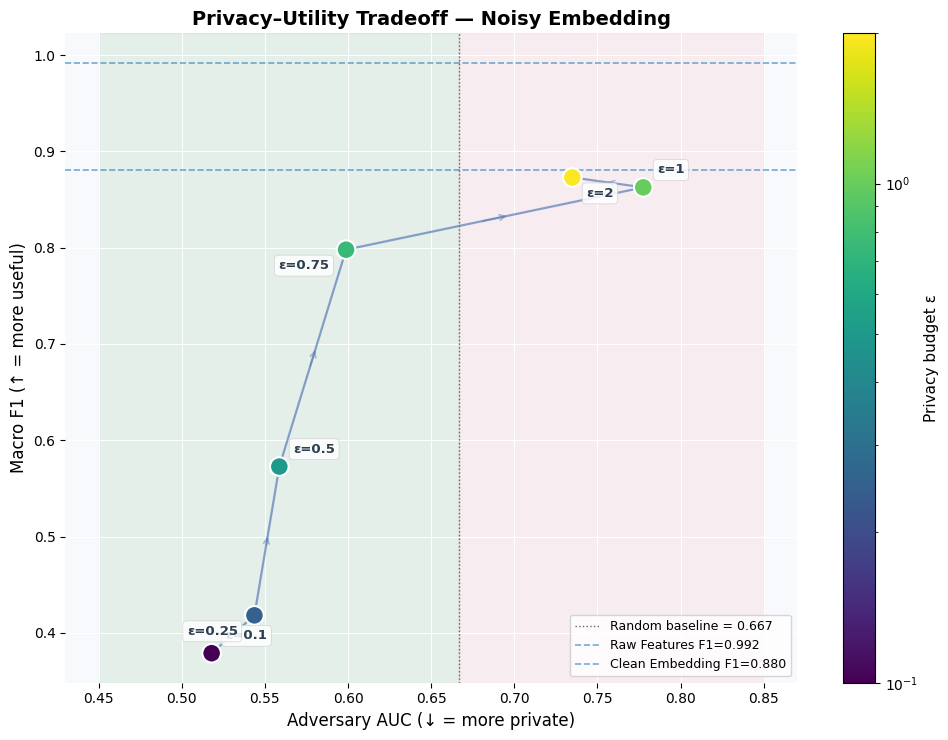

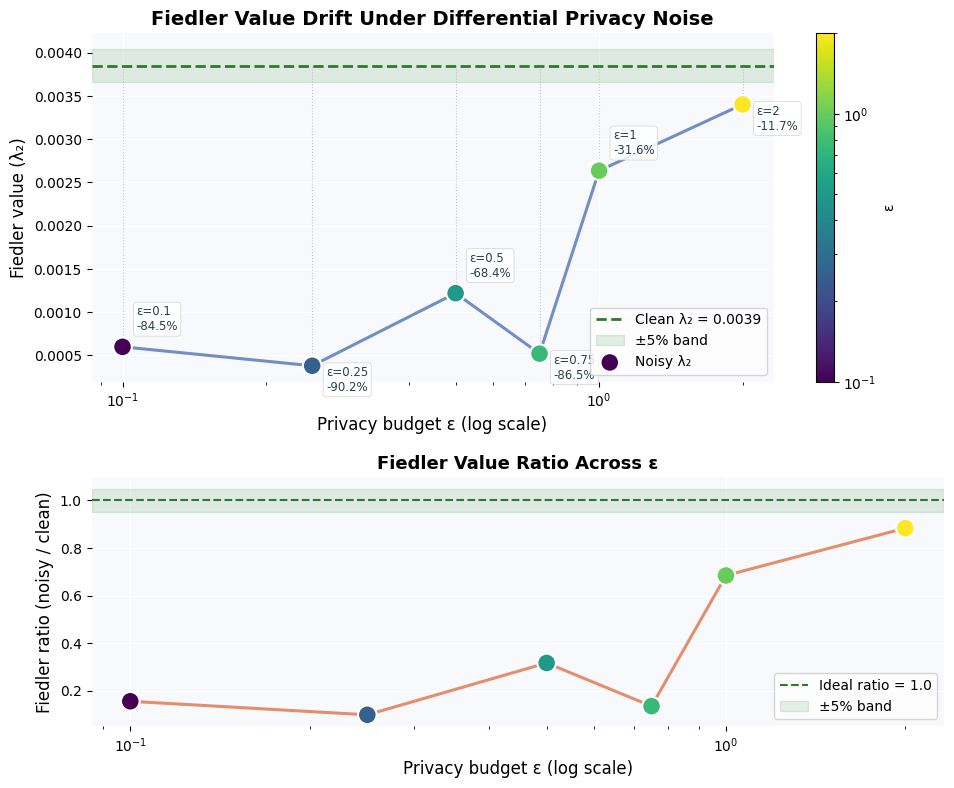

In [12]:
# ── Run epsilon sweep → ExperimentResults ─────────────────────────────────────
# Sweeps all epsilons from experiment.yaml; saves CSVs + figures/
results: ExperimentResults = experiment.run(X_scaled, y, target_names)
print(results)   # ExperimentResults(epsilons=[...], f1_range=[..., ...])

In [13]:
# ── Inspect typed results ─────────────────────────────────────────────────────

# EpsilonRecord — one per ε, full attribute access
rec: EpsilonRecord = results.records[-1]   # highest ε (least noise)
print(f"ε={rec.epsilon}  macro_f1={rec.macro_f1:.4f}  adv_auc={rec.adv_auc:.4f}")
print(f"  privacy_gain={rec.privacy_gain:+.4f}  random_baseline={rec.random_baseline:.4f}")
print(f"  fiedler: {rec.fiedler_clean:.4f} → {rec.fiedler_noisy:.4f}  (ratio {rec.fiedler_ratio:.4f})")
print()

# BaselineRecord — unperturbed reference stages
for br in results.baseline_records:
    print(f"{br.stage:<20}  F1={br.macro_f1:.4f}  adv_auc={br.adv_auc:.4f}")
print()

# DataFrame view (lazy property — built on demand)
results.metrics_df

ε=2.0  macro_f1=0.8729  adv_auc=0.7349
  privacy_gain=-0.0208  random_baseline=0.6667
  fiedler: 0.0039 → 0.0034  (ratio 0.8834)

Raw Features          F1=0.9919  adv_auc=0.9808
Clean Embedding       F1=0.8803  adv_auc=0.7308



,epsilon,macro_f1,adv_auc,adv_accuracy,privacy_gain,random_baseline,noise_scale,spectral_gap,noise_to_gap,fiedler_clean,fiedler_noisy,fiedler_ratio
0,0.10,0.3789,0.518000,0.515467,0.151233,0.666667,0.203430,0.000171,1188.821205,0.003851,0.000598,0.155229
1,0.25,0.4182,0.543733,0.533400,0.133267,0.666667,0.081372,0.000171,475.528482,0.003851,0.000379,0.098319
2,0.50,0.5727,0.558700,0.544933,0.121733,0.666667,0.040686,0.000171,237.764241,0.003851,0.001218,0.316325
3,0.75,0.7979,0.598833,0.593433,0.073233,0.666667,0.027124,0.000171,158.509494,0.003851,0.000519,0.134674
4,1.00,0.8626,0.777533,0.728400,-0.061733,0.666667,0.020343,0.000171,118.882120,0.003851,0.002635,0.684261
5,2.00,0.8729,0.734867,0.687467,-0.020833,0.666667,0.010172,0.000171,59.441060,0.003851,0.003401,0.883350


In [14]:
# ── Inspect noise metadata for one epsilon ────────────────────────────────────
# Run a single forward pass to see the typed SpectralGapMetadata
mechanism = build_noise_mechanism(
    cfg.noise.mechanism, epsilon=cfg.noise.epsilons[2],  # mid-range ε
    **cfg.noise.params,
)
model = DPLaplacianEigenmaps(
    n_neighbors=cfg.graph.n_neighbors,
    n_components=cfg.embedding.n_components,
    noise_mechanism=mechanism,
    normalized=cfg.graph.normalized,
)
result: EmbeddingResult = model.fit_transform(X_scaled)
print(result)
print()

meta = result.noise_metadata
print(f"Mechanism type : {meta.type}")
print(f"Noise scale    : {meta.scale:.6f}")
print(f"Spectral gap   : {meta.gap:.6f}")
print(f"Noise/gap ratio: {meta.noise_to_gap:.4f}")
print(f"Fiedler clean  : {meta.fiedler_gap_clean:.6f}")
print(f"Fiedler noisy  : {meta.fiedler_gap_noisy:.6f}")
print(f"Fiedler ratio  : {meta.fiedler_gap_ratio:.4f}")

EmbeddingResult(samples=8767, components=4, fiedler_clean=0.003851, fiedler_noisy=0.001218, mechanism='spectral_gap')

Mechanism type : spectral_gap
Noise scale    : 0.040686
Spectral gap   : 0.000171
Noise/gap ratio: 237.7642
Fiedler clean  : 0.003851
Fiedler noisy  : 0.001218
Fiedler ratio  : 0.3163


In [15]:
# ── Inspect AttackResult ──────────────────────────────────────────────────────
avg_atk, per_class_atk = run_attack_all_classes(
    result.embedding_noisy, y, list(target_names),
    cv=cfg.evaluation.n_splits, random_state=cfg.evaluation.random_state,
)
print("Class-averaged attack result:")
print(avg_atk)
print(f"  adv_auc        = {avg_atk.adv_auc:.4f}")
print(f"  random_baseline= {avg_atk.random_baseline:.4f}")
print(f"  privacy_gain   = {avg_atk.privacy_gain:+.4f}")
print(f"  is_private     = {avg_atk.is_private}")
print()
display(avg_atk.to_frame())
print()
print("Per-class:")
for cls, atk in zip(target_names, per_class_atk):
    print(f"  {cls}: {atk}")

Class-averaged attack result:
AttackResult(adv_auc=0.5587, priv_gain=+0.1217, status='private')
  adv_auc        = 0.5587
  random_baseline= 0.6667
  privacy_gain   = +0.1217
  is_private     = True



,Adv Accuracy,Random Baseline,Privacy Gain,Norm Gain,Adv F1,Adv AUC
Logistic Regression (LR),0.544933,0.666667,0.121733,-0.425933,0.4267,0.5587



Per-class:
  IR: AttackResult(adv_auc=0.5651, priv_gain=+0.0333, status='private')
  Normal: AttackResult(adv_auc=0.5215, priv_gain=+0.2416, status='private')
  OR: AttackResult(adv_auc=0.5895, priv_gain=+0.0903, status='private')


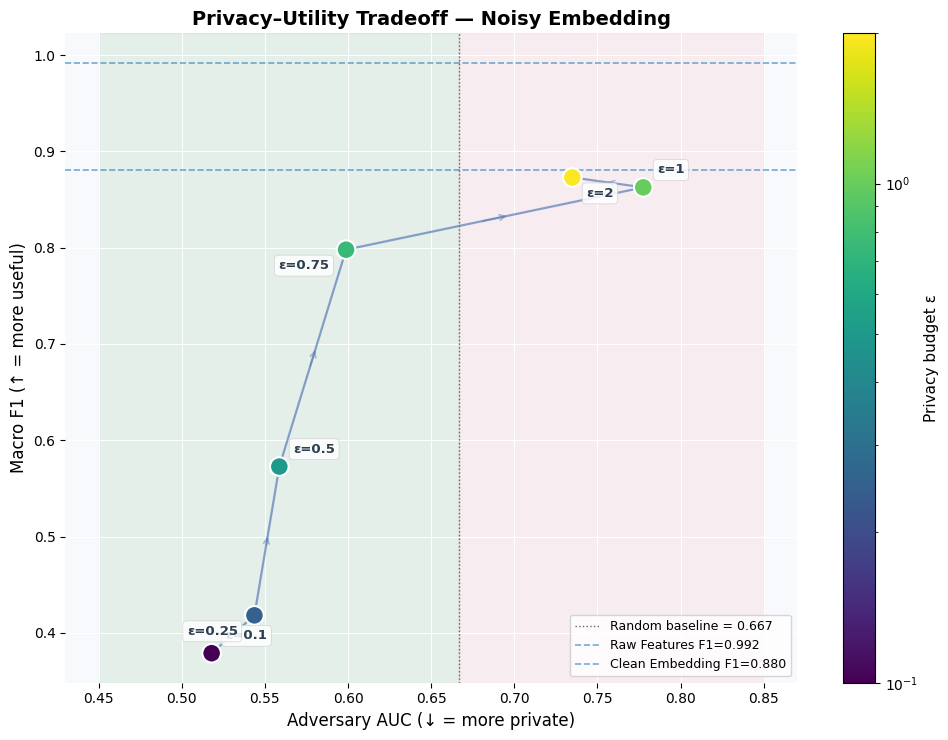

In [16]:
# ── Privacy–utility tradeoff ──────────────────────────────────────────────────
fig = plot_privacy_utility_tradeoff(
    results.records,                        # list[EpsilonRecord]
    baseline_records=results.baseline_records,  # list[BaselineRecord]
)
plt.show()

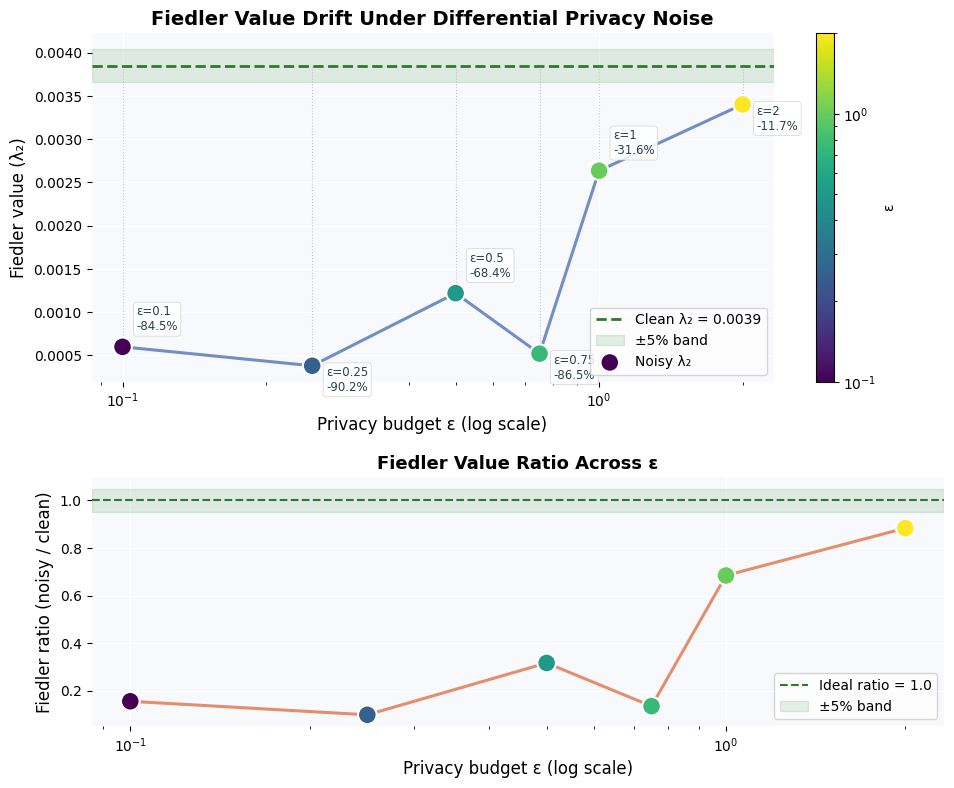

In [17]:
# ── Fiedler gap evolution ─────────────────────────────────────────────────────
fig = plot_fiedler_evolution(results.fiedler_records)  # list[FiedlerRecord]
plt.show()

In [18]:
# ── Deep-dive: classification on clean embedding ──────────────────────────────
clean_model = DPLaplacianEigenmaps(
    n_neighbors=cfg.graph.n_neighbors,
    n_components=cfg.embedding.n_components,
    normalized=cfg.graph.normalized,
)
clean: EmbeddingResult = clean_model.fit_transform(X_scaled)
print(clean)

clf_res: dict[str, ClassifierResult] = run_classification(
    clean.embedding_clean, y, target_names,   # attribute access, not string key
    cv=cfg.evaluation.n_splits,
)
print(f"\nRandom Forest  macro_f1={clf_res['Random Forest'].macro_f1:.4f}")
print(f"SVM            macro_f1={clf_res['SVM'].macro_f1:.4f}")
print()
display_classification_results(clf_res)

EmbeddingResult(samples=8767, components=4, fiedler_clean=0.003851, fiedler_noisy=0.003851, mechanism='none')

Random Forest  macro_f1=0.8800
SVM            macro_f1=0.7639



,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
1,Random Forest,0.875,0.876,0.885,0.880
3,KNN,0.864,0.866,0.873,0.869
4,Decision Tree,0.840,0.845,0.846,0.845
2,SVM,0.765,0.766,0.783,0.764
0,Logistic Regression,0.421,0.557,0.334,0.198


## Three-Way Pipeline Comparison

Compare noise injected at three different stages:
- **Laplacian-space** — perturb L before eigendecomposition (existing)
- **Feature-space** — perturb raw features X before graph construction
- **Embedding-space** — perturb eigenvectors V after Laplacian Eigenmaps

All pipelines share the same ε sweep, snr_target, classifiers, and inference-attack mechanism.

In [19]:
from privacy_pipeline import (
    ComparisonExperiment, ComparisonResults, ComparisonRecord, PipelineMetrics,
    plot_pipeline_comparison, plot_comparison_tradeoff,
    FeatureSpaceNoisePipeline, EmbeddingSpaceNoisePipeline,
)

# ComparisonExperiment reads the same experiment.yaml
cmp_exp = ComparisonExperiment(cfg)
print(cmp_exp.cfg.noise.epsilons)

[0.1, 0.25, 0.5, 0.75, 1.0, 2.0]



── ε = 0.1 ─────────────────────────────
[FeatureNoise ε=0.1] fiedler 3.8505e-03→6.5004e-01 | 79.57s
[EmbeddingNoise ε=0.1] fiedler 3.8505e-03 (L unchanged) | 4.19s
  lap  → F1=0.3737  AUC=0.5180
  feat → F1=0.3259  AUC=0.4947
  emb  → F1=0.3170  AUC=0.5015

── ε = 0.25 ─────────────────────────────
[FeatureNoise ε=0.25] fiedler 3.8505e-03→6.3012e-01 | 85.75s
[EmbeddingNoise ε=0.25] fiedler 3.8505e-03 (L unchanged) | 4.20s
  lap  → F1=0.4193  AUC=0.5437
  feat → F1=0.3399  AUC=0.5529
  emb  → F1=0.3318  AUC=0.5140

── ε = 0.5 ─────────────────────────────
[FeatureNoise ε=0.5] fiedler 3.8505e-03→4.4067e-01 | 77.01s
[EmbeddingNoise ε=0.5] fiedler 3.8505e-03 (L unchanged) | 4.21s
  lap  → F1=0.5733  AUC=0.5587
  feat → F1=0.3688  AUC=0.6074
  emb  → F1=0.3409  AUC=0.5395

── ε = 0.75 ─────────────────────────────
[FeatureNoise ε=0.75] fiedler 3.8505e-03→2.2218e-01 | 69.35s
[EmbeddingNoise ε=0.75] fiedler 3.8505e-03 (L unchanged) | 4.22s
  lap  → F1=0.7979  AUC=0.5988
  feat → F1=0.4176  

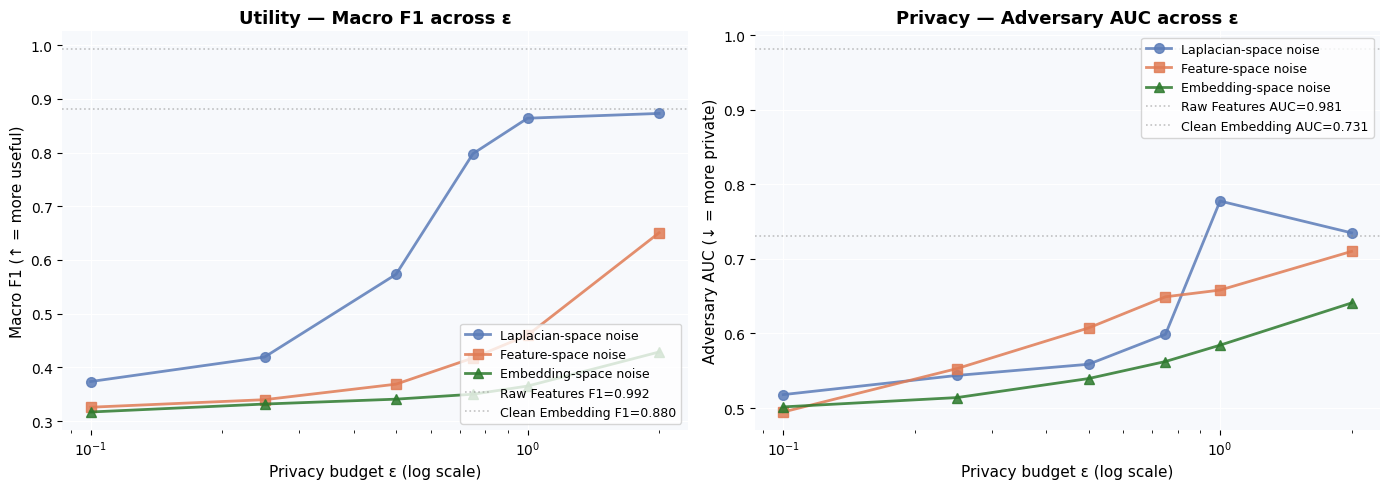

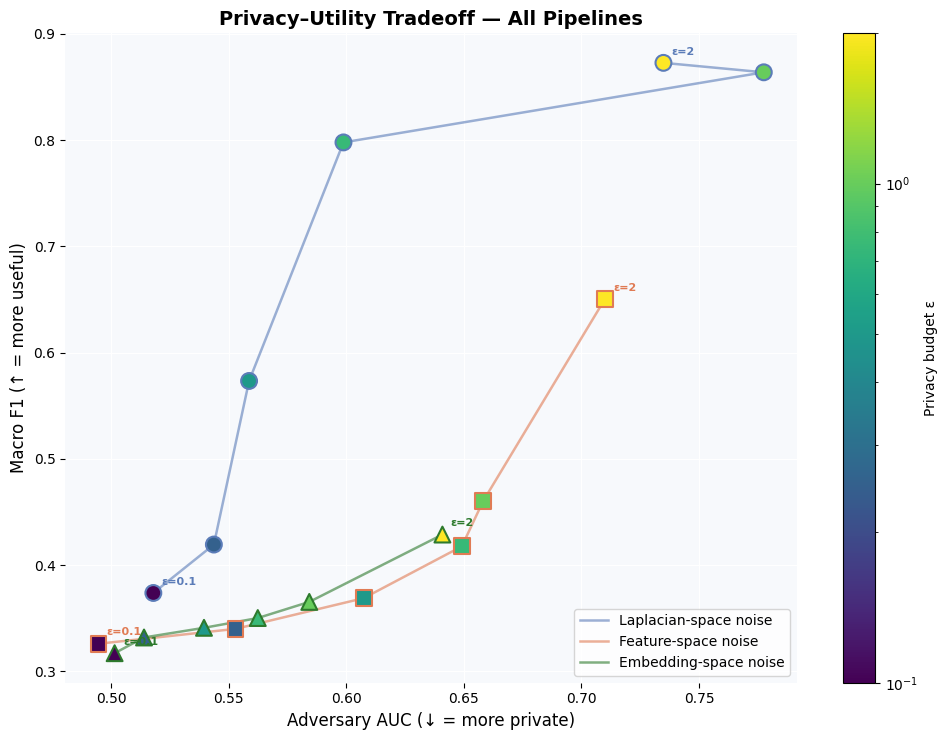

In [20]:
# ── Run three-way comparison sweep ────────────────────────────────────────────
# Uses X_scaled, y, target_names already loaded above
cmp_results: ComparisonResults = cmp_exp.run(X_scaled, y, target_names)
print(cmp_results)

In [21]:
# ── Inspect a single ComparisonRecord ─────────────────────────────────────────
rec: ComparisonRecord = cmp_results.records[-1]   # highest ε (least noise)
print(f"ε = {rec.epsilon}")
print(f"  Laplacian  F1={rec.laplacian.macro_f1:.4f}  AUC={rec.laplacian.adv_auc:.4f}  priv_gain={rec.laplacian.privacy_gain:+.4f}")
print(f"  Feature    F1={rec.feature.macro_f1:.4f}  AUC={rec.feature.adv_auc:.4f}  priv_gain={rec.feature.privacy_gain:+.4f}")
print(f"  Embedding  F1={rec.embedding.macro_f1:.4f}  AUC={rec.embedding.adv_auc:.4f}  priv_gain={rec.embedding.privacy_gain:+.4f}")

ε = 2.0
  Laplacian  F1=0.8728  AUC=0.7349  priv_gain=-0.0208
  Feature    F1=0.6506  AUC=0.7100  priv_gain=+0.0409
  Embedding  F1=0.4287  AUC=0.6409  priv_gain=+0.0680


In [22]:
# ── Long-format DataFrame (one row per ε × pipeline) ──────────────────────────
cmp_results.long_df

,epsilon,pipeline,macro_f1,adv_auc,adv_accuracy,privacy_gain,random_baseline,fiedler_clean,fiedler_noisy
0,0.10,laplacian,0.3737,0.518000,0.515467,0.151233,0.666667,0.003851,0.000598
1,0.10,feature,0.3259,0.494700,0.497700,0.168933,0.666667,0.003851,0.650040
2,0.10,embedding,0.3170,0.501533,0.500233,0.166433,0.666667,0.003851,0.003851
3,0.25,laplacian,0.4193,0.543733,0.533400,0.133267,0.666667,0.003851,0.000379
4,0.25,feature,0.3399,0.552933,0.534500,0.132200,0.666667,0.003851,0.630123
5,0.25,embedding,0.3318,0.514033,0.512067,0.154600,0.666667,0.003851,0.003851
6,0.50,laplacian,0.5733,0.558700,0.544933,0.121733,0.666667,0.003851,0.001218
7,0.50,feature,0.3688,0.607400,0.569167,0.097500,0.666667,0.003851,0.440666
8,0.50,embedding,0.3409,0.539533,0.529933,0.136767,0.666667,0.003851,0.003851
9,0.75,laplacian,0.7979,0.598833,0.593433,0.073233,0.666667,0.003851,0.000519


In [23]:
# ── Wide-format DataFrame (one row per ε) ──────────────────────────────────────
cmp_results.wide_df

,epsilon,lap_f1,lap_auc,lap_priv_gain,feat_f1,feat_auc,feat_priv_gain,emb_f1,emb_auc,emb_priv_gain
0,0.10,0.3737,0.518000,0.151233,0.3259,0.494700,0.168933,0.3170,0.501533,0.166433
1,0.25,0.4193,0.543733,0.133267,0.3399,0.552933,0.132200,0.3318,0.514033,0.154600
2,0.50,0.5733,0.558700,0.121733,0.3688,0.607400,0.097500,0.3409,0.539533,0.136767
3,0.75,0.7979,0.598833,0.073233,0.4176,0.649167,0.073567,0.3501,0.562400,0.118567
4,1.00,0.8639,0.777533,-0.061733,0.4600,0.658167,0.065267,0.3653,0.584300,0.101733
5,2.00,0.8728,0.734867,-0.020833,0.6506,0.710033,0.040933,0.4287,0.640900,0.068033


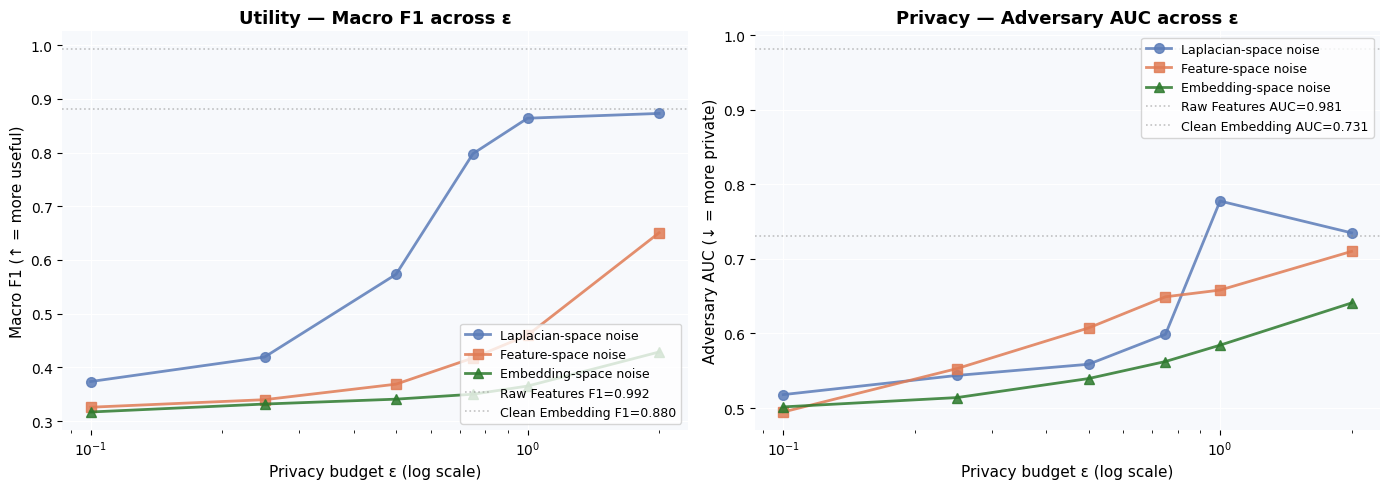

In [24]:
# ── F1 and AUC line plots across ε ────────────────────────────────────────────
fig = plot_pipeline_comparison(cmp_results)
plt.show()

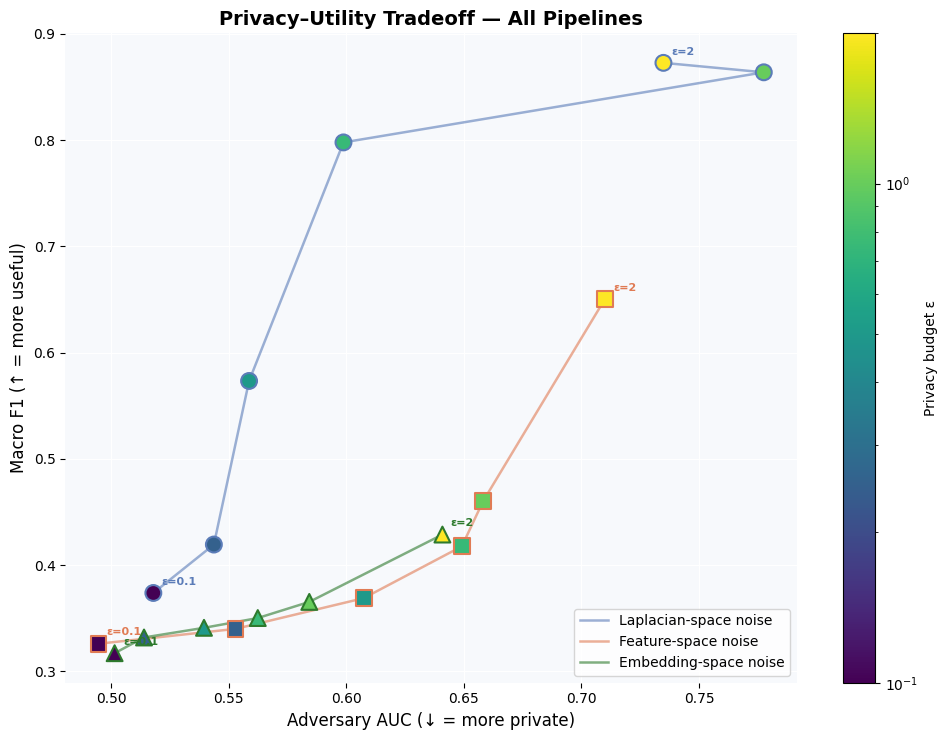

In [25]:
# ── Privacy–utility scatter: all three trajectories ───────────────────────────
fig = plot_comparison_tradeoff(cmp_results)
plt.show()